<a href="https://colab.research.google.com/github/VadimKaryakin/FractalAnalysis/blob/master/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Integral sum

In [1]:
def integral_sum(bright_data):   
    integral_data = np.zeros(bright_data.shape)

    for y in range(bright_data.shape[0]):
        for x in range(bright_data.shape[1]):
            integral_data[y,x] = bright_data[y, x]

            if(y>0 and x>0):
                integral_data[y,x] +=  integral_data[y, x-1]
                integral_data[y,x] +=  integral_data[y-1,x]
                integral_data[y,x] -=  integral_data[y-1,x-1]
            else:
                if(y>0):
                    integral_data[y,x] +=  integral_data[y-1,x]
                if(x>0):                               
                    integral_data[y,x] +=  integral_data[y,x-1] 
    return integral_data

## Фрактальная сигнатура и спектр Реньи




In [2]:
from sklearn import metrics
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from scipy.ndimage import generic_filter
from scipy.stats import linregress
from scipy.spatial import distance

In [3]:
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import multiprocessing
from io import BytesIO
from PIL import Image
from scipy.ndimage.filters import convolve
from scipy.stats import linregress
import seaborn as sns

In [4]:
import matplotlib.patches as mpatches
import math
%matplotlib inline

In [5]:
from scipy.ndimage.filters import maximum_filter, minimum_filter, generic_filter

In [6]:
def fractal_signature(imar, d_=10):
    u = imar.copy()
    b = imar.copy()

    footprint=np.array([[0, 1, 0],
                        [1, 0, 1],
                        [0, 1, 0]])
    ds = range(1, d_)
    vols = []

    for d in ds:
        fst_u = u + 1
        fst_b = b - 1

        scnd_u = maximum_filter(u, mode='constant', footprint=footprint, cval=0)
        scnd_b = minimum_filter(b, mode='constant', footprint=footprint, cval=255)

        u = np.maximum(fst_u, scnd_u)
        b = np.minimum(fst_b, scnd_b)

        vols.append(np.sum(u - b))

    x = -np.log(ds[1:d_-2])
    y = [np.log((vols[i] - vols[i-1])/2) for i in range(1, d_-2)]    
    if (len(x) != len(y)):
      print("Length error")
    return linregress(x, y).slope

In [7]:
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

In [8]:
def reni_entropy(p, q):
    return (1 / (1 - q) * np.log(np.sum(np.power(p, q)))) if q != 1 else (-np.sum(p * np.log(p)))

In [9]:
def get_reni_dim(integ_sum, start_y, start_x, q, eps):
    ws = range(1, eps, 3)
    ns = []
  
    for w in ws:
        conv = []
        for dx in range(start_x, start_x+eps-w, w):
          for dy in range(start_y, start_y+eps-w, w):
            conv.append(integ_sum[dy+w,dx+w] + integ_sum[dy,dx] - integ_sum[dy+w,dx] - integ_sum[dy,dx+w])
        ns.append(reni_entropy(conv / np.sum(conv), q))
    x = -np.log(ws)
    y = ns
    
    return linregress(x, y).slope

In [10]:
def get_reni_spectre(integ_sum, start_y, start_x, qs, eps):
    return list(map(lambda x: get_reni_dim(integ_sum, start_y, start_x, x, eps), qs))

# Признаки Харалика

In [11]:
from skimage.feature import greycomatrix, greycoprops
from skimage import data
from pandas import DataFrame
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing

In [12]:
# def stat(imar):
#   eps = 12
#   stat_features = []

#   for start1, end1 in zip(range(0, imar.shape[0]-eps, eps), range(eps, imar.shape[0], eps)):
#       for start2, end2 in zip(range(0, imar.shape[1]-eps, eps), range(eps, imar.shape[1], eps)):                
#             glcm = greycomatrix(imar[start1:end1, start2:end2], distances=[1], angles=[0], levels=256,
#                           symmetric=True, normed=True)
#             GLCM_feat = []
#             GLCM_feat.append(greycoprops(glcm, 'dissimilarity')[0, 0]) #first parameter - номер в distances
#             GLCM_feat.append(greycoprops(glcm, 'correlation')[0, 0])   #second parameter - номер в angles
#             GLCM_feat.append(greycoprops(glcm, 'contrast')[0, 0])
#             GLCM_feat.append(greycoprops(glcm, 'homogeneity')[0, 0])
#             GLCM_feat.append(greycoprops(glcm, 'energy')[0, 0])
#             GLCM_feat.append(greycoprops(glcm, 'ASM')[0, 0])
#             stat_features.append(GLCM_feat)
#   stat_features = np.array(stat_features)
#   return preprocessing.scale(stat_features)

# Calc features


In [13]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
def reduce_features(data, name, n_components=2):
  if (name == 'tsne'):
    m = TSNE(n_components=n_components).fit_transform(data)
  elif (name == 'pca'):
    m = PCA(n_components=0.95).fit_transform(data)
  else:
    m = TSNE(n_components=n_components).fit_transform(data)
  return m

In [14]:
def draw_reduced_features(data):
  plt.title('reduced_features')
  plt.scatter(cur_data[:, 0], cur_data[:,1])
  plt.show()

In [15]:
def draw_clusters(data, c):
  plt.title('draw_clusters')
  colors = [(0, 204, 0), (255,0,0), (0,255,255), (255,0,255), (255,255,51), \
	          (255,128,0), (255,102,255), (50,50,255), (125,0,125)]
  plt.scatter(cur_data[:, 0], cur_data[:,1], c = c)

In [16]:
def draw_ground_truth(data):
  return true

In [17]:
def Calc(filename, adj_scores):
  img = cv.imread("data/" + filename, cv.IMREAD_GRAYSCALE)
  imar = np.array(img, dtype=np.int16)

  parts = []
  eps = 12

  for start_y, end_y in zip(range(0, imar.shape[0]-eps, eps), range(eps, imar.shape[0], eps)):
    for start_x, end_x in zip(range(0, imar.shape[1]-eps, eps), range(eps, imar.shape[1], eps)):
      parts.append((start_x, start_y))

  ads26 = []
  for part in parts:
    start_x, start_y = part
    ads26.append(fractal_signature(imar[start_y:start_y+eps, start_x:start_x+eps], 10))

  ads10 = []
  eps = 12
  for part in parts:
    start_x, start_y = part
    ads10.append(fractal_signature(imar[start_y:start_y+eps, start_x:start_x+eps], 10))

#перевести из одного вектора во множество
  if np.array(ads10)[0].size == 1:
    ads10 = np.array(ads10).reshape(-1,1)
    ads26 = np.array(ads26).reshape(-1,1)

  ads = np.hstack((ads10, ads26))
  """Renie"""

  im = Image.open("data/" + filename)
  immat = rgb2gray(np.array(im))
#чтобы исключить нулевое значение яркости
  immat *= 254/255
  immat += 1

  q = np.array(range(-10, 10, 3))
#eps - задает размер блоков arange(0, eps)
  eps = 12

  from progressbar import ProgressBar

  parts = []
  specs20 = []

  bar = ProgressBar()

  integ_sum = integral_sum(immat)

  for start_y, end_y in bar(zip(range(0, immat.shape[0]-eps, eps), range(eps, immat.shape[0], eps))):
    for start_x, end_x in zip(range(0, immat.shape[1]-eps, eps), range(eps, immat.shape[1], eps)):
      parts.append((start_x, start_y))        
      specs20.append(get_reni_spectre(integ_sum, start_y, start_x, q, eps))

  """Signature + Renie"""
  specs20 = np.array(specs20)
  #specs20_scaled = preprocessing.scale(specs20)
  #ads_scaled = preprocessing.scale(ads)
  
  united_features = np.hstack((specs20, ads))
  #united_features = ads_scaled
  
  """Haralick texture features"""
  # stat_features = []
  # for start_y, end_y in zip(range(0, immat.shape[0]-eps, eps), range(eps, immat.shape[0], eps)):
  #   for start_x, end_x in zip(range(0, immat.shape[1]-eps, eps), range(eps, immat.shape[1], eps)):     
  #     values = []
  #     values.append(np.array(immat[start_y:end_y, start_x:end_x]).mean())
  #     values.append(np.array(immat[start_y:end_y, start_x:end_x]).var())
  #     stat_features.append(values)
  """Histogram features"""
  #united_features = np.hstack((united_features, preprocessing.scale(stat_features)))
  #united_features = np.hstack((united_features, stat(imar)))

  return united_features, parts

In [18]:
def find_best_k(data):
  scores = []
  K = range(2,7)
  for no_of_clusters in K:
    gm = GaussianMixture(n_components=no_of_clusters, random_state=0).fit(data)
    scores.append(metrics.silhouette_score(data, gm.predict(data), metric='euclidean'))
    print("mean silouette score for ",  no_of_clusters, "=", scores[-1])
  return np.argmax(scores) + 2

In [19]:
def describe(data):
  d = pd.DataFrame(data)

  d.hist(bins=100, figsize=(30,30))
  plt.savefig("hist.png", dpi=300)

  #Используется корреляция Пирсона?
  df_corr = d.corr()
  df_corr.to_csv("corr.csv")
  fig, ax = plt.subplots(figsize=(10, 8))
  # mask
  mask = np.triu(np.ones_like(df_corr, dtype=np.bool))
  # adjust mask and df
  mask = mask[1:, :-1]
  corr = df_corr.iloc[1:,:-1].copy()
  # plot heatmap
  sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Blues',\
            vmin=-1, vmax=1, cbar_kws={"shrink": .8})
  # yticks
  plt.yticks(rotation=0)
  plt.show()
  
  plt.savefig("./train_corrs.png", dpi=300)

  d.describe().to_csv("my_description.csv")

  # sns.violinplot(d[d.columns[1]])

In [20]:
from sklearn.mixture import GaussianMixture

def cluster_and_assess(pca_norm, k, filename, parts):
  #kmeans = KMeans(n_clusters=k).fit(pca_norm)
  #c=kmeans.labels_.astype(int)
  gm = GaussianMixture(n_components=k, random_state=0).fit(pca_norm)
  c = gm.predict(pca_norm).astype(int)

  colors = [(0, 204, 0), (255,0,0), (0,255,255), (255,0,255), (255,255,51), \
	          (255,128,0), (255,102,255), (50,50,255), (125,0,125)]
  qq = cv.imread("data/" + filename, cv.COLOR_BGR2RGB)
  for i in range(0, len(parts)):
    cv.circle(qq, parts[i], 3, colors[c[i]], -1)
  cv.imwrite("result/" + filename, qq)
  np.savetxt("values/" + filename[:-4] + ".csv", pca_norm, delimiter=",")
  np.savetxt("coordinates.csv", parts, delimiter=",")
  #np.savetxt("values/cluster_centers" + filename[:-4] + ".csv", kmeans.cluster_centers_, delimiter=",")

  """Assess"""
  import math
  size = math.ceil(math.sqrt(len(parts)))
  labels_pred = np.zeros(len(parts)).astype(int)
  patch_size = size//2

  for i in range(0, size, 2):
    labels_pred[i*patch_size:(i+1)*patch_size] = 0
  for i in range(1, size, 2):
    labels_pred[i*patch_size:(i+1)*patch_size] = 1
  for i in range(size, size*2, 2):
    labels_pred[i*patch_size:(i+1)*patch_size] = 2
  for i in range(size+1, size*2, 2):
    labels_pred[i*patch_size:(i+1)*patch_size] = 3

  # with np.printoptions(threshold=np.inf):
  #    print(c)

  adj_scores.append(metrics.adjusted_rand_score(c, labels_pred))
  return c

##Main

In [21]:
import os
path = os.getcwd() 
adj_scores = []

In [22]:
from os import listdir
from os.path import isfile, join 
onlyfiles = [f for f in listdir(path+ "/data") if isfile(join(path+ "/data", f))]

In [23]:
if not os.path.isdir("/content/result"):
  os.makedirs("/content/result", mode=511, exist_ok=False)
if not os.path.isdir("/content/values"):
  os.makedirs("/content/values", mode=511, exist_ok=False)

0merged.png


| |         #                                        | 84 Elapsed Time: 0:00:30


step1


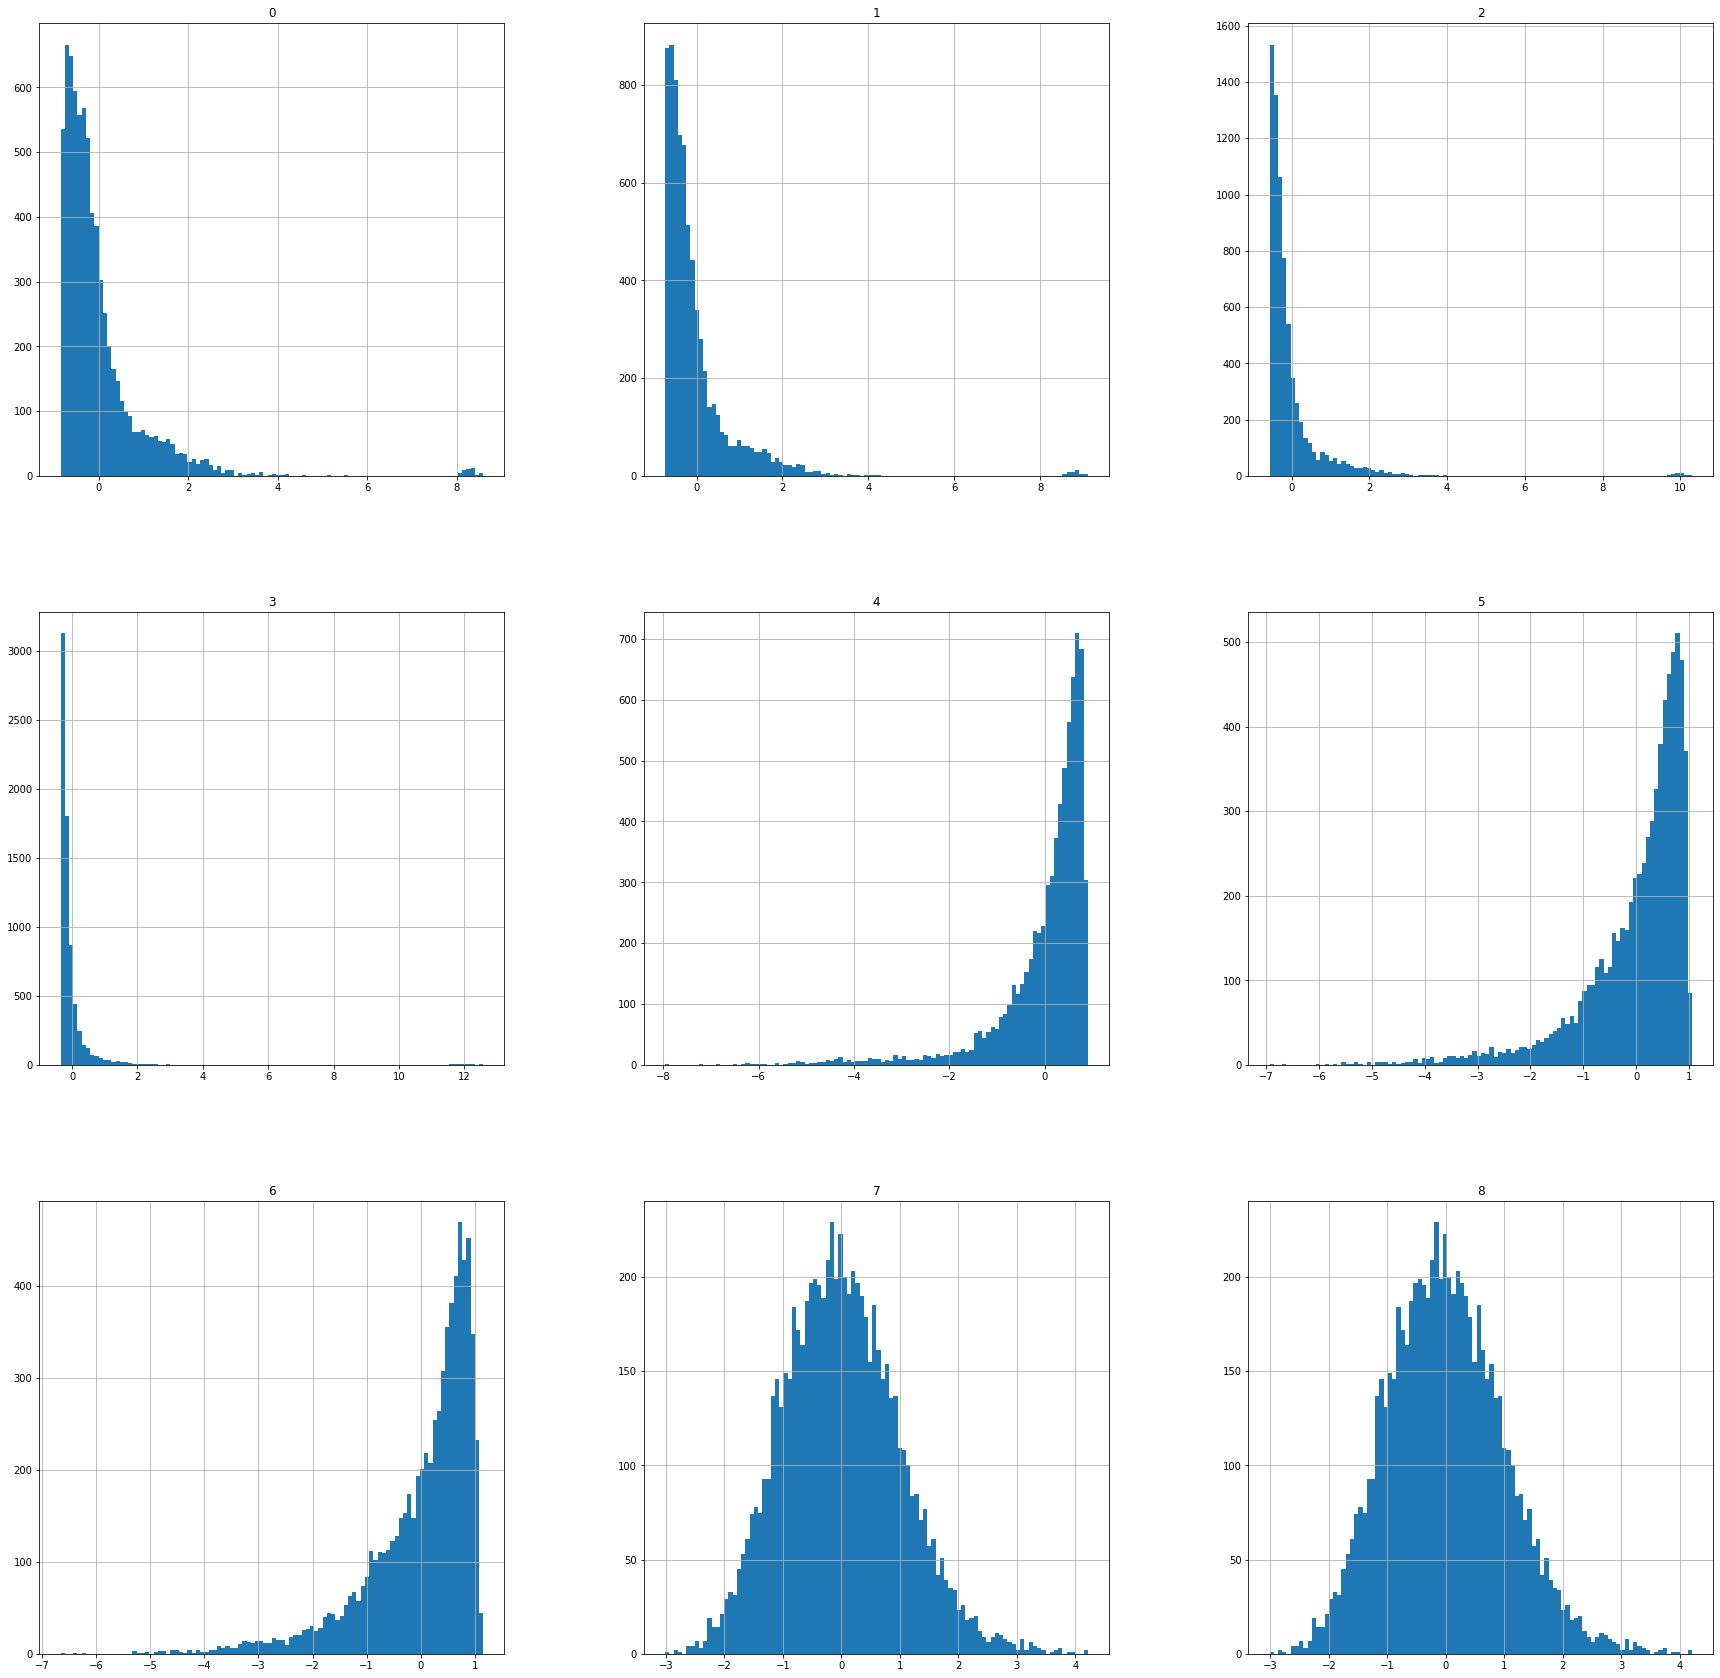

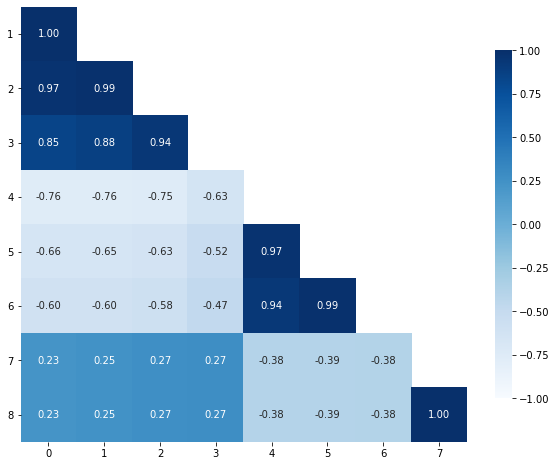

step2


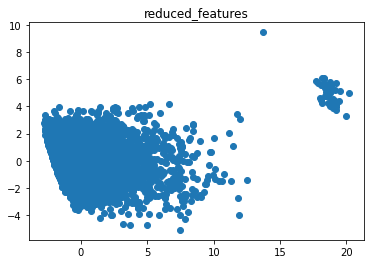

step3
mean silouette score for  2 = 0.41026205063896576
mean silouette score for  3 = 0.31714969238168206
mean silouette score for  4 = 0.16403592706616701
mean silouette score for  5 = 0.08009809374093811
mean silouette score for  6 = 0.09956155023030241
step4
step5
step6


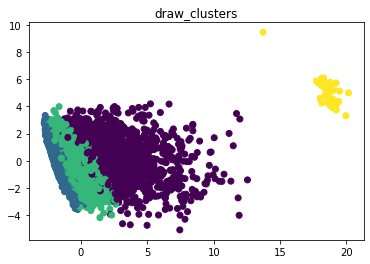

In [24]:
for elem in onlyfiles:
  print(elem)
  cur_data, parts = Calc(elem, adj_scores)
  cur_data = preprocessing.scale(cur_data)
  print('step1')
  describe(cur_data)
  print('step2')
  cur_data = reduce_features(cur_data, 'pca', 2)
  draw_reduced_features(cur_data)
  print('step3')
  k = find_best_k(cur_data)
  print('step4')
  frag = cluster_and_assess(cur_data, 4, elem, parts)
  print('step5')
  draw_clusters(cur_data, frag)
  print('step6')

In [25]:
with open('scores.txt', 'w') as f:
    for item in adj_scores:
        f.write("%s\n" % item)
    f.write("Mean:")
    f.write("%s\n" % np.mean(adj_scores))

In [26]:
# !zip -r /content/result.zip /content/result
# !zip -r /content/values.zip /content/values
# !zip -r /content/data.zip   /content/data

In [27]:
from google.colab import files
# files.download("/content/result.zip")
# files.download("/content/values.zip")
# files.download("/content/data.zip")
# files.download("/content/scores.txt")
# files.download("/content/coordinates.csv")